# 🔍 Pseudo-Labels Analysis Report
Questo notebook permette di esplorare step-by-step i risultati generati dal Teacher Model sull'IEMOCAP (Sessioni 1, 2, 3).

### 1. Setup & Imports

In [2]:
import os
import sys
import json
import torch
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from tabulate import tabulate

# Setup paths per importare config.py e i moduli
NOTEBOOK_DIR = Path(os.getcwd())
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'NoisyStudent_train' else NOTEBOOK_DIR
sys.path.insert(0, str(PROJECT_ROOT))

import config as Config
from dataset.custom_iemocap_dataset import CustomIEMOCAPDataset

EMOTIONS = ['neutral', 'happy', 'sad', 'angry']
print(f"✅ Setup completato. Project root: {PROJECT_ROOT}")

✅ Setup completato. Project root: d:\Roba da D\Poli\ML Vision\speech-emotion-recognition-25


### 2. Caricamento Pseudo-Labels
Carichiamo il file JSON generato dallo step precedente (`generate_pseudo_labels.py`).

In [3]:
json_path = PROJECT_ROOT / "NoisyStudent_train" / "pseudo_labels_iemocap.json"
if not json_path.exists():
    raise FileNotFoundError(f"❌ Error: File pseudo-labels non trovato: {json_path}\nEsegui prima generate_pseudo_labels.py!")

with open(json_path, 'r') as f:
    pseudo_labels = json.load(f)
    
total_accepted = len(pseudo_labels)
print(f"📂 Caricate correttamente {total_accepted} pseudo-labels ad alta confidenza dal JSON.")

📂 Caricate correttamente 450 pseudo-labels ad alta confidenza dal JSON.


### 3. Recupero Ground Truth dall'IEMOCAP
Carichiamo le etichette reali dell'IEMOCAP (Sessioni 1, 2, 3) per confrontarle con quelle inventate dal Teacher.

In [5]:
print("📥 Recupero Ground Truth (Sessioni 1, 2, 3)...")
unlabeled_speakers = {'1F','1M','2F','2M','3F','3M'}
dataset = CustomIEMOCAPDataset(
    dataset_root=str(PROJECT_ROOT / Config.IEMOCAP_PATH),
    allowed_speakers=unlabeled_speakers,
    is_train=False
)

y_true = []
y_pred = []
dist_pred = {0:0, 1:0, 2:0, 3:0}
dist_true = {0:0, 1:0, 2:0, 3:0}
missing_samples = 0

for sample in dataset.samples:
    sample_id = sample['sample_id']
    if sample_id in pseudo_labels:
        true_label = dataset.EMOTION_ID_MAP[sample['label']]
        pred_label = pseudo_labels[sample_id]
        
        y_true.append(true_label)
        y_pred.append(pred_label)
        
        dist_pred[pred_label] += 1
        dist_true[true_label] += 1
    else:
        missing_samples += 1

total_dataset_samples = len(dataset.samples)
print(f"\n📊 Campioni totali dataset (Session 1-3 impro): {total_dataset_samples}")
print(f"🎯 Campioni Accettati (Confidenza >= {getattr(Config, 'CONFIDENCE_THRESHOLD', 0.7)}): {len(y_pred)} ({(len(y_pred)/total_dataset_samples)*100:.2f}%)")
print(f"🗑️ Campioni Scartati (Bassa confidenza): {missing_samples} ({(missing_samples/total_dataset_samples)*100:.2f}%)")

📥 Recupero Ground Truth (Sessioni 1, 2, 3)...
✅ Caricate 5531 etichette
🔍 Raccogliendo campioni audio...
✅ Raccolti 1678 campioni audio validi
   - Solo campioni improvvisati
   - Emozioni: ['neutral', 'happy', 'sad', 'angry', 'happy']
📊 Statistiche del dataset IEMOCAP:

📊 ANALISI IEMOCAP EVALUATION SET

🔹 SAMPLES TOTALI: 1678
🔹 SESSIONI: ['1', '2', '3']
🔹 SPEAKER UNICI (session, gender): 6
   Elenco: [('1', 'F'), ('1', 'M'), ('2', 'F'), ('2', 'M'), ('3', 'F'), ('3', 'M')]
🔹 IMPROVVISAZIONI UNICHE: 12
   Elenco: ['01', '02', '03', '04', '05', '05a', '05b', '06', '07', '08', '08a', '08b']

👥 SPEAKER INDEPENDENCE (per verificare leakage):
   - Sessione 1: (Ses1, F), (Ses1, M)
   - Sessione 2: (Ses2, F), (Ses2, M)
   - Sessione 3: (Ses3, F), (Ses3, M)

🎭 DISTRIBUZIONE EMOZIONI:
   - Angry     :  174 ( 10.4%) ██
   - Happy     :  472 ( 28.1%) █████
   - Neutral   :  638 ( 38.0%) ███████
   - Sad       :  394 ( 23.5%) ████

📋 DISTRIBUZIONE CAMPIONI PER SESSIONE:
   - Sessione 1:  521 ( 31.0

### 4. Analisi Sbilanciamento delle Classi
Verifichiamo quante volte il Teacher ha predetto una certa classe.

In [6]:
print("⚖️ CLASS DISTRIBUTION (IN ACCEPTED PSEUDO-LABELS)\n")
dist_table = []
for emotion_id, emotion_name in enumerate(EMOTIONS):
    count_pred = dist_pred[emotion_id]
    count_true = dist_true[emotion_id]
    pct_pred = (count_pred / len(y_pred)) * 100 if len(y_pred) > 0 else 0
    dist_table.append([emotion_name.capitalize(), count_pred, f"{pct_pred:.1f}%", count_true])
    
print(tabulate(dist_table, headers=["Emotion", "Predicted (Teacher)", "Pseudo-Label %", "Ground Truth (Actual)"], tablefmt="pretty"))
print("\n⚠️ Se c'è un forte sbilanciamento (es. troppi Neutral), lo Student potrebbe faticare a imparare classi più rare.")

⚖️ CLASS DISTRIBUTION (IN ACCEPTED PSEUDO-LABELS)

+---------+---------------------+----------------+-----------------------+
| Emotion | Predicted (Teacher) | Pseudo-Label % | Ground Truth (Actual) |
+---------+---------------------+----------------+-----------------------+
| Neutral |         68          |     15.1%      |          161          |
|  Happy  |         146         |     32.4%      |          152          |
|   Sad   |         183         |     40.7%      |          70           |
|  Angry  |         53          |     11.8%      |          67           |
+---------+---------------------+----------------+-----------------------+

⚠️ Se c'è un forte sbilanciamento (es. troppi Neutral), lo Student potrebbe faticare a imparare classi più rare.


### 5. Metriche di Qualità del Teacher
Accuracy e Classification Report sulle predizioni accettate.

In [7]:
print("🧠 TEACHER QUALITY (SULLE PREDICIONS AD ALTA CONFIDENZA)\n")
accuracy = accuracy_score(y_true, y_pred)
print(f"Accuracy of Accepted Pseudo-Labels: {accuracy*100:.2f}%\n")
print(classification_report(y_true, y_pred, target_names=EMOTIONS))

🧠 TEACHER QUALITY (SULLE PREDICIONS AD ALTA CONFIDENZA)

Accuracy of Accepted Pseudo-Labels: 35.78%

              precision    recall  f1-score   support

     neutral       0.41      0.17      0.24       161
       happy       0.48      0.46      0.47       152
         sad       0.19      0.50      0.28        70
       angry       0.53      0.42      0.47        67

    accuracy                           0.36       450
   macro avg       0.40      0.39      0.36       450
weighted avg       0.42      0.36      0.36       450



### 6. Matrice di Confusione

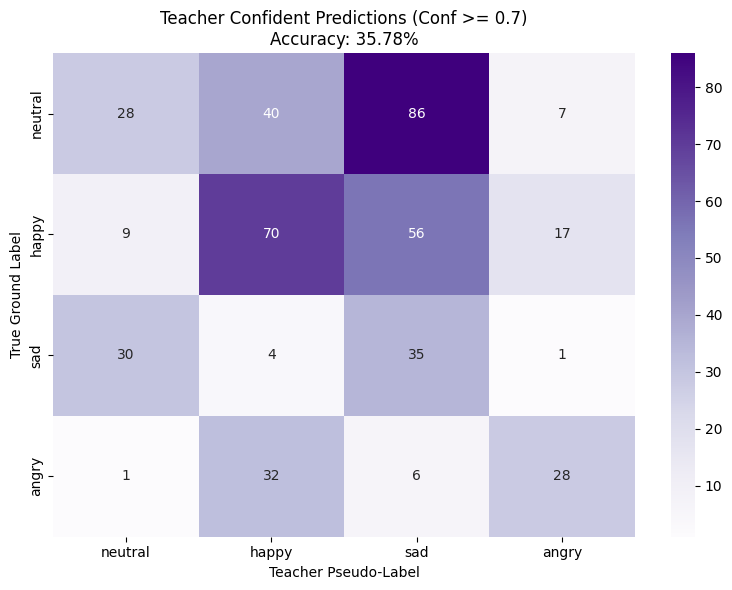

In [8]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', 
            xticklabels=EMOTIONS, yticklabels=EMOTIONS)

plt.title(f"Teacher Confident Predictions (Conf >= {getattr(Config, 'CONFIDENCE_THRESHOLD', 0.7)})\nAccuracy: {accuracy*100:.2f}%")
plt.ylabel('True Ground Label')
plt.xlabel('Teacher Pseudo-Label')
plt.tight_layout()
plt.show()